# 05 — Intent-tree recovery: extracted vs. DiscoverLLM ground truth

**The thesis comparison.** For each DiscoverLLM artifact we have (a) the **ground-truth** intent tree
DiscoverLLM generated the conversation from, and (b) the tree we **extracted** from that same
conversation (`gpt-5.4-mini`, in `data/extractions_discoverllm/`). This notebook measures how well the
extraction *recovers* the ground-truth intents.

**Method**

- **Scope (default): green + yellow (surfaced).** The conversation only reveals nodes the GT marks
  `satisfied` (green) or `aware` (yellow); it can't surface `not-discovered` (red) nodes, so we score
  against green+yellow. The last cell also reports a **pure-green** (satisfied-only) variant for comparison.
- **Semantic node matching (NLP):** embed each node's text (OpenAI `text-embedding-3-small`), then score
  cosine matches above a threshold under **two regimes** — strict **1-1 (Hungarian, optimal assignment)**
  and **many-to-one (coverage / set-overlap)** where one extracted node may cover several GT nodes →
  **precision / recall / F1** for each. Coverage is the most generous regime (an *upper bound* on
  recovery); comparing the two tells you whether a low 1-1 score is a granularity/matching artifact.
- **Structural fidelity:** **ancestor-preservation** — when the extraction nests A above B, does GT agree?

## Sources, metrics, caveats

- **Extracted:** `data/extractions_discoverllm/*.json` (schema `trees[].nodes[]` with `label`, `parent_id`).
- **Ground truth:** `data/discoverllm_creative_writing_conversations.csv` `trees` column (nested
  `{id, text, children, aware, satisfied}`).

**Discovery colors:** green = `satisfied>0`, yellow = `aware>0 & satisfied==0`, red = neither.
**Metrics:** `recall` = GT intents recovered; `precision` = extracted nodes matching a GT intent;
`anc_keep` = of the extraction's ancestor links among matched nodes, the fraction GT agrees with.
Threshold `SIM_THRESHOLD = 0.55`; small N (15 artifacts).

In [1]:
import os
import json
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from openai import OpenAI

def _repo_root():
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "requirements.txt").exists() and (cand / "notebooks").is_dir():
            return cand
    return Path.cwd()

ROOT = _repo_root()
load_dotenv(ROOT / ".env")
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

EMBED_MODEL = "text-embedding-3-small"
SIM_THRESHOLD = 0.55   # cosine cutoff for a valid node match

try:
    from scipy.optimize import linear_sum_assignment
    def match(sim):
        if sim.size == 0:
            return []
        ri, ci = linear_sum_assignment(-sim)
        return [(int(r), int(c)) for r, c in zip(ri, ci) if sim[r, c] >= SIM_THRESHOLD]
except Exception:                      # greedy fallback if scipy is absent
    def match(sim):
        pairs, ur, uc = [], set(), set()
        for r, c in np.dstack(np.unravel_index(np.argsort(-sim, axis=None), sim.shape))[0]:
            if sim[r, c] < SIM_THRESHOLD:
                break
            if r in ur or c in uc:
                continue
            ur.add(r); uc.add(c); pairs.append((int(r), int(c)))
        return pairs

In [2]:
# --- Load extracted trees (gpt-5.4-mini) and ground-truth DiscoverLLM trees ---
def _loads(s):
    try:
        return json.loads(s)
    except Exception:
        return ast.literal_eval(s)

EXT_DIR = ROOT / "data" / "extractions_discoverllm"
extracted = {}
for f in sorted(EXT_DIR.glob("*.json")):
    d = json.loads(f.read_text())
    if not d.get("error"):
        extracted[f.stem] = d
print(f"extracted artifacts: {len(extracted)}  | extractor(s): {sorted({d.get('model') for d in extracted.values()})}")

gt_df = pd.read_csv(ROOT / "data" / "discoverllm_creative_writing_conversations.csv")
gt = {r["artifact_id"]: _loads(r["trees"]) for _, r in gt_df.iterrows()}
ids = sorted(set(extracted) & set(gt))
print(f"GT artifacts: {len(gt)}  | overlap (compared here): {len(ids)}")

extracted artifacts: 15  | extractor(s): ['gpt-5.4-mini']
GT artifacts: 495  | overlap (compared here): 15


In [3]:
# --- Flatten helpers (GT scope is parameterized) ---
def extracted_nodes(doc):
    out = []
    for ti, t in enumerate(doc.get("trees", [])):
        nodes = t.get("nodes", [])
        by = {n["id"]: n for n in nodes}
        for n in nodes:
            anc, cur = set(), n
            while cur.get("parent_id") is not None and cur["parent_id"] in by:
                cur = by[cur["parent_id"]]
                anc.add((ti, cur["id"]))
            text = (n.get("label") or "").strip()
            if text:
                out.append({"key": (ti, n["id"]), "text": text, "anc": anc})
    return out

def _keep(n, scope):
    if scope == "green":                                       # discovered only
        return n.get("satisfied", 0) > 0
    return n.get("aware", 0) > 0 or n.get("satisfied", 0) > 0   # surfaced = green + yellow (default)

def gt_nodes(trees, scope="surfaced"):
    out = []
    def walk(n):
        yield n
        for c in n.get("children", []):
            yield from walk(c)
    for t in trees:
        for n in walk(t):
            if not _keep(n, scope):
                continue
            nid = str(n["id"]); parts = nid.split(".")
            anc = {".".join(parts[:k]) for k in range(1, len(parts))}   # dot-path prefixes
            text = (n.get("text") or "").strip()
            if text:
                out.append({"key": nid, "text": text, "anc": anc})
    return out

def gt_total(trees):
    def walk(n):
        return 1 + sum(walk(c) for c in n.get("children", []))
    return sum(walk(t) for t in trees)

In [4]:
# --- Embed every unique node text once (green is a subset of surfaced, so one pass covers both) ---
all_texts = set()
for aid in ids:
    all_texts.update(n["text"] for n in extracted_nodes(extracted[aid]))
    all_texts.update(n["text"] for n in gt_nodes(gt[aid], "surfaced"))
all_texts = sorted(all_texts)
print(f"embedding {len(all_texts)} unique node texts via {EMBED_MODEL} ...")

vec = {}
B = 1000
for i in range(0, len(all_texts), B):
    chunk = all_texts[i:i + B]
    resp = client.embeddings.create(model=EMBED_MODEL, input=chunk)
    for t, e in zip(chunk, resp.data):
        v = np.asarray(e.embedding, dtype=np.float32)
        vec[t] = v / (np.linalg.norm(v) + 1e-9)   # L2-normalize -> dot == cosine
print("done.")

embedding 283 unique node texts via text-embedding-3-small ...
done.


In [5]:
# --- Per-artifact matching + metrics, parameterized by GT scope ---
def cos(ext, gtn):
    E = np.vstack([vec[n["text"]] for n in ext])
    G = np.vstack([vec[n["text"]] for n in gtn])
    return E @ G.T

def run(scope):
    rows, examples = [], []
    for aid in ids:
        ext = extracted_nodes(extracted[aid])
        gtn = gt_nodes(gt[aid], scope)
        n_ext, n_gt, n_gt_all = len(ext), len(gtn), gt_total(gt[aid])
        if n_ext == 0 or n_gt == 0:
            rows.append({"artifact": aid, "n_ext": n_ext, "n_gt": n_gt, "n_gt_all": n_gt_all,
                         "precision": np.nan, "recall": np.nan, "f1": np.nan, "anc_keep": np.nan})
            continue
        sim = cos(ext, gtn)
        pairs = match(sim)
        m = len(pairs)
        precision, recall = m / n_ext, m / n_gt
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        me = {r: c for r, c in pairs}
        keep = tot = 0
        for i in me:
            for j in me:
                if i != j and ext[i]["key"] in ext[j]["anc"]:
                    tot += 1
                    keep += gtn[me[i]]["key"] in gtn[me[j]]["anc"]
        # many-to-one / set-overlap: a GT node is recovered if ANY extracted node clears the threshold;
        # an extracted node is "used" if it matches ANY GT node (one extracted node may cover many GT).
        rec_cov = float((sim.max(axis=0) >= SIM_THRESHOLD).mean())
        prec_cov = float((sim.max(axis=1) >= SIM_THRESHOLD).mean())
        f1_cov = 2 * prec_cov * rec_cov / (prec_cov + rec_cov) if (prec_cov + rec_cov) else 0.0
        rows.append({"artifact": aid, "n_ext": n_ext, "n_gt": n_gt, "n_gt_all": n_gt_all,
                     "precision": round(precision, 3), "recall": round(recall, 3),
                     "f1": round(f1, 3), "anc_keep": round(keep / tot, 3) if tot else np.nan,
                     "prec_cov": round(prec_cov, 3), "rec_cov": round(rec_cov, 3), "f1_cov": round(f1_cov, 3)})
        if scope == "surfaced" and len(examples) < 2:
            examples.append((aid, [(ext[r]["text"], gtn[c]["text"], round(float(sim[r, c]), 2)) for r, c in pairs]))
    return pd.DataFrame(rows), examples

# DEFAULT scope = green + yellow (surfaced)
res, examples = run("surfaced")
print(res.to_string(index=False))

    artifact  n_ext  n_gt  n_gt_all  precision  recall    f1  anc_keep  prec_cov  rec_cov  f1_cov
artifact_107      7     6        30      0.571   0.667 0.615     0.333     0.571    0.667   0.615
artifact_149      8    12        29      0.375   0.250 0.300     1.000     0.375    0.417   0.395
artifact_166      9     3        33      0.111   0.333 0.167       NaN     0.111    1.000   0.200
artifact_191      5    25        31      0.600   0.120 0.200       NaN     0.600    0.280   0.382
artifact_194     11    12        39      0.273   0.250 0.261     0.000     0.273    0.500   0.353
artifact_242     11     6        36      0.455   0.833 0.588     1.000     0.545    0.833   0.659
artifact_261      9    19        26      0.333   0.158 0.214     0.000     0.333    0.211   0.258
artifact_277      9     5        27      0.111   0.200 0.143       NaN     0.111    0.200   0.143
artifact_283      9    21        30      0.444   0.190 0.267     1.000     0.444    0.286   0.348
artifact_288      9 

=== green+yellow (surfaced): matching comparison (mean over 15 artifacts) ===
           1-1 (Hungarian)  many-to-one (coverage)
precision            0.309                   0.341
recall               0.327                   0.489
f1                   0.286                   0.361
ancestor-preservation (1-1): 0.435

recall delta (coverage - 1-1)    = +0.162
precision delta (coverage - 1-1) = +0.032

INTERPRETATION (coverage matching is the MOST generous regime = an UPPER BOUND on recovery):
  - recall rises 0.33 -> 0.49: part of the low 1-1 recall is a granularity/matching effect
    (one coarse extracted node covering several fine GT criteria) -> don't claim the exact 1-1 number.
  - BUT even at this upper bound, 51% of surfaced GT intent has NO extracted node within
    threshold -> a real recovery gap remains (the negative result is softened, not erased).
  - precision barely moves (+0.03): low precision is NOT a matching artifact -> most extracted
    nodes have no surfaced-GT coun

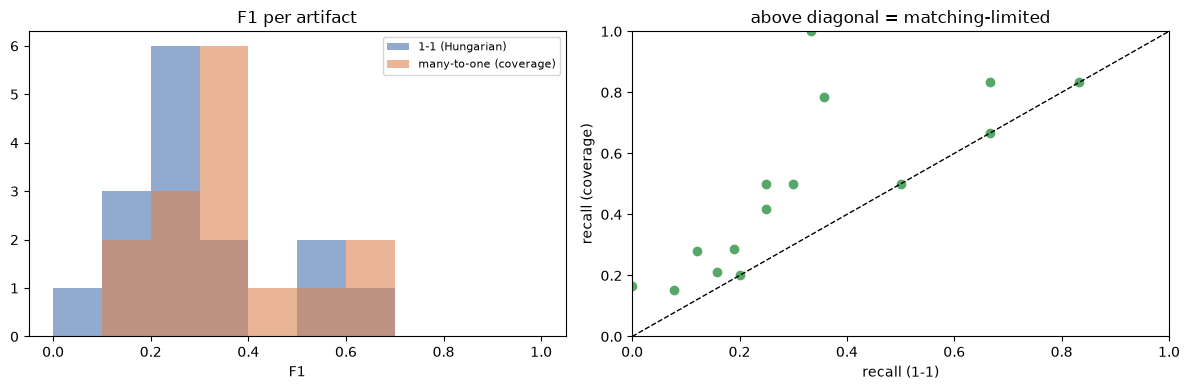


--- artifact_107: 1-1 matched  (cos)  extracted  <->  GT ---
  0.61  Fatal accident premise                     <-> Protagonist faces a fatal accident scenari
   0.7  Supernatural protagonist                   <-> Protagonist possesses supernatural abiliti
  0.57  Sensory detail emphasis                    <-> Incorporates concrete sensory details rela
  0.58  Car crash accident                         <-> Protagonist faces a car crash scenario

--- artifact_149: 1-1 matched  (cos)  extracted  <->  GT ---
  0.63  Moral corruption short story               <-> Depicts moral decay or corruption
  0.87  First-person narration                     <-> First-person narrative perspective
  0.58  Defiant ending                             <-> Concludes with declaration of independence


In [6]:
# --- DECISIVE TEST: 1-1 (Hungarian) vs many-to-one (coverage) matching ---
# If P/R jump under many-to-one, the low 1-1 numbers are a matching/granularity artifact (one coarse
# extracted node can legitimately cover several fine GT criteria) and recovery can't be claimed as low.
match_cmp = pd.DataFrame({
    "1-1 (Hungarian)":        res[["precision", "recall", "f1"]].mean().round(3).values,
    "many-to-one (coverage)": res[["prec_cov", "rec_cov", "f1_cov"]].mean().round(3).values,
}, index=["precision", "recall", "f1"])
print(f"=== green+yellow (surfaced): matching comparison (mean over {int(res['f1'].notna().sum())} artifacts) ===")
print(match_cmp.to_string())
print(f"ancestor-preservation (1-1): {res['anc_keep'].mean():.3f}")
r1, rc = match_cmp.loc["recall", "1-1 (Hungarian)"], match_cmp.loc["recall", "many-to-one (coverage)"]
dr = rc - r1
dp = match_cmp.loc["precision", "many-to-one (coverage)"] - match_cmp.loc["precision", "1-1 (Hungarian)"]
print(f"\nrecall delta (coverage - 1-1)    = {dr:+.3f}")
print(f"precision delta (coverage - 1-1) = {dp:+.3f}")
print("\nINTERPRETATION (coverage matching is the MOST generous regime = an UPPER BOUND on recovery):")
print(f"  - recall rises {r1:.2f} -> {rc:.2f}: part of the low 1-1 recall is a granularity/matching effect")
print(f"    (one coarse extracted node covering several fine GT criteria) -> don't claim the exact 1-1 number.")
print(f"  - BUT even at this upper bound, {1 - rc:.0%} of surfaced GT intent has NO extracted node within")
print(f"    threshold -> a real recovery gap remains (the negative result is softened, not erased).")
print(f"  - precision barely moves ({dp:+.2f}): low precision is NOT a matching artifact -> most extracted")
print(f"    nodes have no surfaced-GT counterpart at all.")
print(f"GT nodes scored (green+yellow): {int(res['n_gt'].sum())} of {int(res['n_gt_all'].sum())} "
      f"({res['n_gt'].sum() / max(res['n_gt_all'].sum(), 1) * 100:.0f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
b = np.arange(0, 1.05, 0.1)
axes[0].hist(res["f1"].dropna(), bins=b, alpha=0.6, label="1-1 (Hungarian)", color="#4C72B0")
axes[0].hist(res["f1_cov"].dropna(), bins=b, alpha=0.6, label="many-to-one (coverage)", color="#DD8452")
axes[0].set_title("F1 per artifact"); axes[0].set_xlabel("F1"); axes[0].legend(fontsize=8)
axes[1].scatter(res["recall"], res["rec_cov"], c="#55A868"); axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].set_xlabel("recall (1-1)"); axes[1].set_ylabel("recall (coverage)")
axes[1].set_title("above diagonal = matching-limited")
plt.tight_layout(); plt.show()

for aid, pairs in examples:
    print(f"\n--- {aid}: 1-1 matched  (cos)  extracted  <->  GT ---")
    for et, gtt, s in pairs:
        print(f"  {s:>4}  {et[:42]:42} <-> {gtt[:42]}")

In [7]:
# --- Non-default readout: PURE GREEN (satisfied-only) GT scope, for comparison ---
green_res, _ = run("green")
def _mean(df):
    return df[["precision", "recall", "f1", "anc_keep"]].mean(numeric_only=True).round(3)
cmp = pd.DataFrame({"green+yellow (default)": _mean(res), "green only": _mean(green_res)})
print(cmp.to_string())
print(f"\nGT nodes scored:  green+yellow = {int(res['n_gt'].sum())}   green-only = {int(green_res['n_gt'].sum())}")
print("(green-only is a stricter, smaller target: only `satisfied` nodes — usually higher recall, lower precision.)")

           green+yellow (default)  green only
precision                   0.309       0.182
recall                      0.327       0.318
f1                          0.286       0.193
anc_keep                    0.435       0.500

GT nodes scored:  green+yellow = 162   green-only = 119
(green-only is a stricter, smaller target: only `satisfied` nodes — usually higher recall, lower precision.)


## Takeaways & next steps

- **Read the matching comparison first.** The 1-1 vs many-to-one table decides what is claimable. A *low*
  1-1 recovery can only be reported as an extraction-quality result if the coverage (many-to-one) numbers
  stay near it; a large coverage jump means the 1-1 figure is a granularity/matching artifact (one coarse
  extracted node legitimately subsuming several fine GT criteria). Coverage is an **upper bound**, so the
  honest claim is bounded by it: "even under the most generous matching, X% of surfaced intent is missed."
- **Precision is the cleaner signal.** It is near-invariant to matching regime — most extracted nodes have
  no surfaced-GT counterpart at all (over-generation / different abstraction), and that *isn't* an artifact.
- **Default scope = green + yellow (surfaced).** `recall` = surfaced GT intent recovered; `precision` =
  extracted nodes matching a GT intent; `anc_keep` = nesting agreement. Red nodes are never scored.
- The pure-green cell is a stricter, smaller target (recall ~holds, precision falls).
- **To scale:** extract more artifacts (`python scripts/extract_intent_trees.py --discoverllm --n N`).
- **Robustness upgrades:** sweep `SIM_THRESHOLD` (the coverage jump is threshold-dependent); stronger
  embedding model; tree-edit distance for structure.